# Fase 3 - Analise (Camada Gold)
Projeto Pipeline ETL - Viagens a Servico / Portal da Transparencia

Este notebook responde as 4 perguntas de negocio do projeto:
- **Pergunta 1** (Camada Silver): viagens urgentes custam mais por dia do que as nao urgentes?
- **Pergunta 2** (Camada Silver): como o custo medio diario varia conforme a faixa de duracao da viagem?
- **Pergunta 3** (Camada Gold): como o valor total pago evoluiu mes a mes e qual tipo de pagamento sustenta essa evolucao?
- **Pergunta 4** (Camada Gold): qual e o perfil de gasto dos orgaos pagadores?


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import text
from banco import get_engine

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

engine = get_engine()
print("Conexao com o banco estabelecida.")


Conexao com o banco estabelecida.


## Pergunta 1 (Camada Silver)
**Viagens classificadas como urgentes custam mais por dia do que as nao urgentes?**


In [2]:
query_1 = """
SELECT
    viagem_urgente,
    ROUND(AVG(custo_medio_diario), 2) AS custo_medio_diario_medio,
    COUNT(*) AS qtd_viagens
FROM silver.silver_viagem
GROUP BY viagem_urgente
ORDER BY custo_medio_diario_medio DESC;
"""

df_pergunta1 = pd.read_sql(query_1, con=engine)
df_pergunta1


,viagem_urgente,custo_medio_diario_medio,qtd_viagens
0,SIM,597.08,203949
1,NÃO,441.95,137911


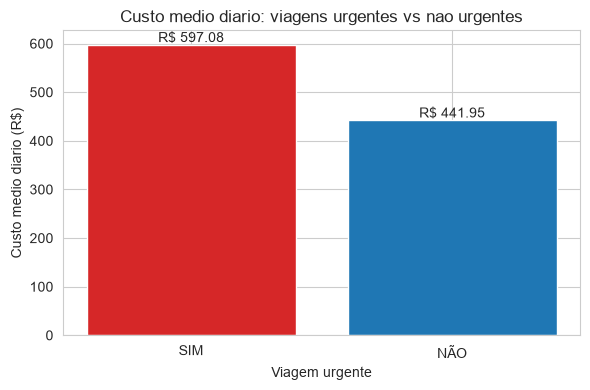

In [3]:
fig, ax = plt.subplots(figsize=(6, 4))
cores = {"SIM": "#d62728", "NAO": "#1f77b4", "NÃO": "#1f77b4"}
barras = ax.bar(
    df_pergunta1["viagem_urgente"],
    df_pergunta1["custo_medio_diario_medio"],
    color=[cores.get(v, "#888888") for v in df_pergunta1["viagem_urgente"]],
)
ax.set_title("Custo medio diario: viagens urgentes vs nao urgentes")
ax.set_xlabel("Viagem urgente")
ax.set_ylabel("Custo medio diario (R$)")
for barra, valor in zip(barras, df_pergunta1["custo_medio_diario_medio"]):
    ax.text(barra.get_x() + barra.get_width() / 2, valor, f"R$ {valor:,.2f}",
            ha="center", va="bottom")
plt.tight_layout()
plt.show()


**Análise:**

Viagens classificadas como urgentes apresentam custo médio diário de R$ 597,08,
cerca de 35% superior ao das viagens não urgentes (R$ 441,95). O grupo "SIM" também
concentra a maior parte do volume (203.949 viagens contra 137.911 do grupo "NÃO").
Esse resultado confirma a hipótese de que a falta de planejamento prévio eleva os
custos, provavelmente por conta de passagens compradas com pouca antecedência.

## Pergunta 2 (Camada Silver)
**Como o custo medio diario varia conforme a faixa de duracao da viagem?**


In [4]:
query_2 = """
WITH viagens_com_faixa AS (
    SELECT
        custo_medio_diario,
        CASE
            WHEN duracao_dias = 1 THEN '1 dia'
            WHEN duracao_dias BETWEEN 2 AND 3 THEN '2-3 dias'
            WHEN duracao_dias BETWEEN 4 AND 7 THEN '4-7 dias'
            WHEN duracao_dias BETWEEN 8 AND 15 THEN '8-15 dias'
            ELSE '16+ dias'
        END AS faixa_duracao,
        CASE
            WHEN duracao_dias = 1 THEN 1
            WHEN duracao_dias BETWEEN 2 AND 3 THEN 2
            WHEN duracao_dias BETWEEN 4 AND 7 THEN 3
            WHEN duracao_dias BETWEEN 8 AND 15 THEN 4
            ELSE 5
        END AS ordem_faixa
    FROM silver.silver_viagem
)
SELECT
    faixa_duracao,
    ROUND(AVG(custo_medio_diario), 2) AS custo_medio_diario_medio,
    COUNT(*) AS qtd_viagens
FROM viagens_com_faixa
GROUP BY faixa_duracao, ordem_faixa
ORDER BY ordem_faixa;
"""

df_pergunta2 = pd.read_sql(query_2, con=engine)
df_pergunta2


,faixa_duracao,custo_medio_diario_medio,qtd_viagens
0,1 dia,502.04,53979
1,2-3 dias,577.66,108236
2,4-7 dias,546.21,121542
3,8-15 dias,544.34,33874
4,16+ dias,341.50,24229


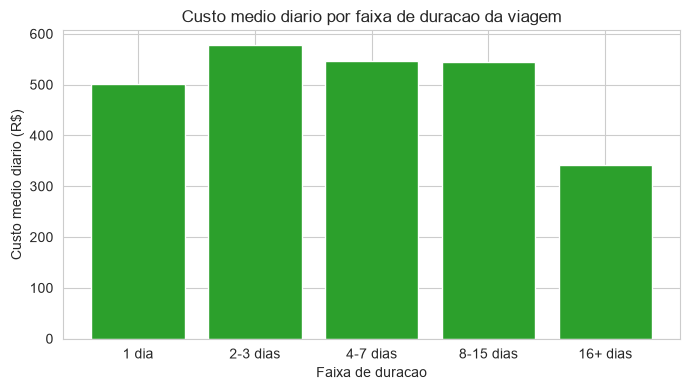

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(df_pergunta2["faixa_duracao"], df_pergunta2["custo_medio_diario_medio"], color="#2ca02c")
ax.set_title("Custo medio diario por faixa de duracao da viagem")
ax.set_xlabel("Faixa de duracao")
ax.set_ylabel("Custo medio diario (R$)")
plt.tight_layout()
plt.show()


**Analise:**

_(Complete este paragrafo apos rodar as celulas acima. Comente a tendencia observada --
por exemplo, se viagens mais curtas tem custo medio diario mais alto por concentrarem
gastos fixos como passagem em poucos dias, enquanto viagens longas diluem esse custo.)_


## Criacao da Camada Gold

A tabela `gold.gold_resumo_pagamentos_mensais` agrega `silver_pagamento` + `silver_viagem`
(via JOIN por `id_viagem`) agrupando por mes de inicio da viagem, tipo de pagamento e
orgao pagador. Essa tabela agregada e a base para responder as Perguntas 3 e 4, e tambem
e disponibilizada como VIEW.


In [6]:
sql_gold = """
CREATE SCHEMA IF NOT EXISTS gold;

DROP VIEW IF EXISTS gold.vw_resumo_pagamentos_mensais;
DROP TABLE IF EXISTS gold.gold_resumo_pagamentos_mensais;

CREATE TABLE gold.gold_resumo_pagamentos_mensais AS
SELECT
    date_trunc('month', v.data_inicio)::date AS mes_referencia,
    p.tipo_pagamento,
    p.nome_orgao_pagador,
    COUNT(*) AS qtd_pagamentos,
    SUM(p.valor) AS valor_total_pago
FROM silver.silver_pagamento p
JOIN silver.silver_viagem v ON p.id_viagem = v.id_viagem
WHERE v.data_inicio IS NOT NULL
GROUP BY 1, 2, 3;

CREATE VIEW gold.vw_resumo_pagamentos_mensais AS
SELECT * FROM gold.gold_resumo_pagamentos_mensais;
"""

with engine.begin() as conexao:
    conexao.execute(text(sql_gold))

print("Camada Gold criada: tabela e view gold.gold_resumo_pagamentos_mensais")


Camada Gold criada: tabela e view gold.gold_resumo_pagamentos_mensais


**Análise:**

O custo medio diario nao segue uma relacao linear com a duracao da viagem. Viagens de
"2-3 dias" tem o maior custo medio diario (R$ 577,66), seguidas por "4-7 dias"
(R$ 546,21) e "8-15 dias" (R$ 544,34). Ja viagens de "16+ dias" apresentam o menor
custo medio diario (R$ 341,50) -- uma queda expressiva em relacao as demais faixas.
Isso sugere que gastos fixos (como passagem aerea) pesam proporcionalmente mais em
viagens curtas, enquanto viagens longas diluem esse custo ao longo de mais dias.

## Pergunta 3 (Camada Gold)
**Como o valor total pago evoluiu mes a mes e qual tipo de pagamento sustenta essa evolucao?**


In [7]:
query_3 = """
SELECT
    mes_referencia,
    tipo_pagamento,
    SUM(valor_total_pago) AS valor_total_pago
FROM gold.gold_resumo_pagamentos_mensais
GROUP BY mes_referencia, tipo_pagamento
ORDER BY mes_referencia, tipo_pagamento;
"""

df_pergunta3 = pd.read_sql(query_3, con=engine)
df_pergunta3


,mes_referencia,tipo_pagamento,valor_total_pago
0,2025-01-01,DIÁRIAS,2.564537e+08
1,2025-01-01,PASSAGEM,3.184762e+07
2,2025-01-01,RESTITUIÇÃO,2.757355e+05
3,2025-01-01,Serviço correlato: seguro,1.744111e+05
4,2025-02-01,DIÁRIAS,7.432670e+07
5,2025-02-01,PASSAGEM,4.431010e+07
6,2025-02-01,RESTITUIÇÃO,3.135702e+05
7,2025-02-01,Serviço correlato: seguro,2.599419e+05
8,2025-03-01,DIÁRIAS,1.361966e+08
9,2025-03-01,PASSAGEM,6.737929e+07


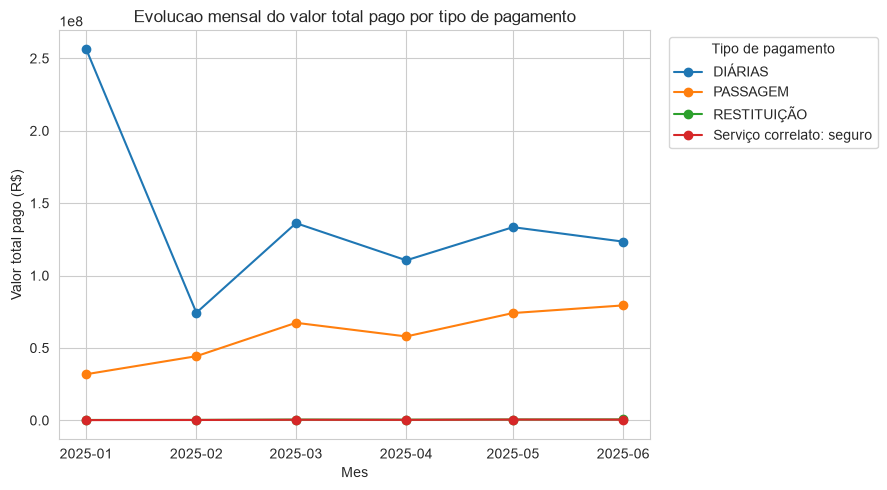

In [8]:
pivot_3 = df_pergunta3.pivot(index="mes_referencia", columns="tipo_pagamento", values="valor_total_pago").fillna(0)

fig, ax = plt.subplots(figsize=(9, 5))
pivot_3.plot(marker="o", ax=ax)
ax.set_title("Evolucao mensal do valor total pago por tipo de pagamento")
ax.set_xlabel("Mes")
ax.set_ylabel("Valor total pago (R$)")
ax.legend(title="Tipo de pagamento", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


**Análise:**

O tipo de pagamento "DIARIAS" sustenta a maior parte do valor total pago em todos os
meses analisados, com destaque para um pico expressivo em janeiro/2025 (cerca de
R$ 250 milhoes), bem acima da media dos meses seguintes (entre R$ 110 e R$ 130
milhoes). "PASSAGEM" mantem uma tendencia de leve crescimento ao longo do semestre.
Os tipos "RESTITUICAO" e "Servico correlato: seguro" tem participacao pouco expressiva
no valor total, permanecendo proximos de zero na escala do grafico. O pico de janeiro
merece investigacao adicional -- pode estar relacionado a pagamentos retroativos de
viagens realizadas no fim do ano anterior.


## Pergunta 4 (Camada Gold)
**Qual e o perfil de gasto dos orgaos pagadores (muitos pagamentos de valor baixo ou
poucos pagamentos de valor alto)?**


In [9]:
query_4 = """
SELECT
    nome_orgao_pagador,
    SUM(qtd_pagamentos) AS qtd_pagamentos,
    SUM(valor_total_pago) AS valor_total_pago,
    ROUND(SUM(valor_total_pago) / NULLIF(SUM(qtd_pagamentos), 0), 2) AS valor_medio_pagamento
FROM gold.gold_resumo_pagamentos_mensais
GROUP BY nome_orgao_pagador
ORDER BY valor_total_pago DESC
LIMIT 15;
"""

df_pergunta4 = pd.read_sql(query_4, con=engine)
df_pergunta4


,nome_orgao_pagador,qtd_pagamentos,valor_total_pago,valor_medio_pagamento
0,Fundo Nacional de Segurança Pública,79816.0,2.784810e+08,3489.04
1,Sigiloso,93141.0,2.004848e+08,2152.49
2,Comando da Aeronáutica,46193.0,8.176914e+07,1770.16
3,Instituto Nacional do Seguro Social,18324.0,3.742760e+07,2042.55
4,Comando do Exército,22837.0,3.687264e+07,1614.60
5,Ministério da Gestão e da Inovação em Serviços...,20291.0,3.554176e+07,1751.60
6,Instituto Brasileiro do Meio Ambiente e dos Re...,16758.0,3.158985e+07,1885.06
7,Ministério das Relações Exteriores - Unidades ...,3705.0,2.560538e+07,6911.03
8,Receita Federal do Brasil,18917.0,2.381103e+07,1258.71
9,Ministério da Agricultura e Pecuária - Unidade...,15864.0,2.289988e+07,1443.51


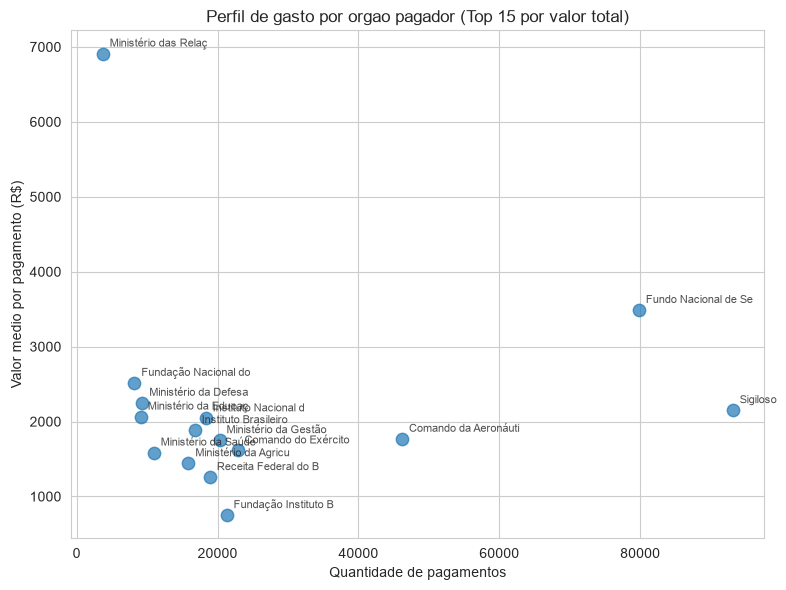

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df_pergunta4["qtd_pagamentos"], df_pergunta4["valor_medio_pagamento"], s=80, alpha=0.7)

for _, linha in df_pergunta4.iterrows():
    ax.annotate(
        linha["nome_orgao_pagador"][:20],
        (linha["qtd_pagamentos"], linha["valor_medio_pagamento"]),
        fontsize=8, alpha=0.8, xytext=(5, 5), textcoords="offset points",
    )

ax.set_title("Perfil de gasto por orgao pagador (Top 15 por valor total)")
ax.set_xlabel("Quantidade de pagamentos")
ax.set_ylabel("Valor medio por pagamento (R$)")
plt.tight_layout()
plt.show()


**Análise:**

Os orgaos pagadores apresentam perfis de gasto distintos. O Ministerio das Relacoes
Exteriores se destaca por fazer poucos pagamentos, porem com valor medio muito alto
(proximo de R$ 7.000 por pagamento) -- coerente com o custo elevado de viagens
diplomaticas internacionais. Ja orgaos como o "Fundo Nacional de Saude" e um orgao
identificado como "Sigiloso" concentram um volume muito maior de pagamentos (70 a 85
mil), com valor medio moderado (entre R$ 2.000 e R$ 3.500). A maioria dos demais
orgaos analisados fica no perfil intermediario: poucos pagamentos e valores medios
mais baixos.


## Conclusao

A analise dos seis meses de dados de viagens a servico (2025) revelou padroes
consistentes de comportamento de custo. Viagens urgentes custam, em media, 35% mais
por dia do que as planejadas com antecedencia (R$ 597,08 vs R$ 441,95), reforcando a
importancia do planejamento previo na reducao de gastos publicos. A relacao entre
duracao e custo diario tambem chamou atencao: nao e uma queda linear e gradual --
viagens de 2 a 3 dias sao proporcionalmente as mais caras por dia (R$ 577,66), e so a
partir de 16+ dias o custo diario cai de forma expressiva (R$ 341,50), sugerindo que
gastos fixos como passagem pesam mais em viagens curtas.

Na camada Gold, o destaque foi o pico de pagamentos do tipo "DIARIAS" em janeiro de
2025 (~R$ 250 milhoes), quase o dobro da media dos meses seguintes. Esse padrao
merece investigacao adicional em uma proxima iteracao do projeto -- uma hipotese e
que parte desses valores corresponda a pagamentos retroativos de viagens realizadas
no ano anterior, mas isso exigiria cruzar com a data de emissao do pagamento
(nao disponivel na granularidade mensal usada aqui). Na analise por orgao pagador,
ficou evidente que orgaos como o Ministerio das Relacoes Exteriores tem poucos
pagamentos de valor unitario alto (viagens diplomaticas internacionais), enquanto
orgaos como o Fundo Nacional de Saude concentram um volume alto de pagamentos de
valor mais modesto -- perfis de gasto bem diferentes que pedem estrategias de
controle orcamentario tambem diferentes. Vale registrar tambem que um dos orgaos
pagadores aparece identificado apenas como "Sigiloso" nos dados publicos, um lembrete
de que a transparencia do Portal tem excecoes legais.

**Possiveis melhorias futuras para o pipeline:**
- Ampliar o recorte temporal para o ano completo (ou anos anteriores), permitindo
  identificar sazonalidade real e nao apenas um pico isolado em janeiro;
- Investigar o pico de janeiro cruzando com a data de emissao do pagamento
  (raw_pagamento nao possui essa coluna, mas raw_passagem tem "data da emissao/compra",
  o que poderia indicar se pagamentos de janeiro se referem a viagens de dezembro);
- Cruzar a camada Gold com a tabela silver_trecho, para entender se destinos
  especificos (nacionais vs internacionais) explicam parte da variacao de custo;
- Adicionar uma quinta pergunta de negocio sobre o volume de "missoes" (coluna
  Missao? da raw_trecho, ainda nao explorada);
- Transformar essa analise em um dashboard interativo (ex: Streamlit ou Power BI),
  permitindo que gestores publicos filtrem por orgao, mes ou faixa de duracao sem
  precisar rodar consultas SQL manualmente.
